In [16]:
"""
Модуль 7. Поиск аномалий и Fraud Detection

Задача: Выявление нетипичных паттернов в потоке транзакций (мошенничество, ошибки, инсайд).

Методология:
1. Isolation Forest (Лес изоляции) – алгоритм, специально созданный для обнаружения аномалий.
   Он изолирует наблюдения, случайно разделяя пространство признаков. Аномалии требуют меньшего количества
   разбиений для изоляции, поэтому их "путь" в дереве короче.

2. Deep Autoencoder – нейросетевая модель, которая сжимает входные данные до низкоразмерного представления
   (bottleneck), а затем восстанавливает их. Ошибка реконструкции (MSE) служит мерой аномальности:
   для нетипичных транзакций модель не сможет хорошо восстановить вход, и ошибка будет высокой.

Источник данных: Kaggle "Credit Card Fraud Detection"
Признаки: Time (секунды от первой транзакции), Amount (сумма), V1..V28 (анонимизированные PCA-компоненты)
Целевая переменная: Class (0 – легитимная, 1 – мошенническая) – используется только для оценки.

Наша задача – без использования меток классов (Unsupervised Learning) обучить модели,
которые будут отмечать подозрительные транзакции.

https://disk.yandex.ru/d/cfb50D7hyedMgg
"""


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report
from sklearn.ensemble import IsolationForest
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ==========================
# 1. ЗАГРУЗКА И ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ
# ==========================
# Предполагается, что файл creditcard.csv находится в текущей директории
#print("Загрузка данных creditcard.csv...")
df = pd.read_csv('./creditcard.csv')

# TODO 1.1: Выведите информацию о датафрейме (размер, типы, пропуски) и статистику.
print(f"Статистика: ")
df.describe()

# TODO 1.2: Проверьте сбалансированность классов. Посчитайте количество и долю мошеннических транзакций.
df['Class'].sum()/df['Class'].count() # <ВАШ_КОД>

# ==========================
# 2. ПОДГОТОВКА ПРИЗНАКОВ
# ==========================
# Признаки: V1..V28, Time, Amount. Целевая переменная 'Class' не используется при обучении моделей.
# Создадим копию признаков.

X = df.drop('Class', axis=1).copy()
y = df['Class'].copy()  # для финальной оценки

# # TODO 2.1: Примените логарифмическое преобразование к признаку Amount (np.log1p) – это полезно для уменьшения влияния выбросов.
# np.log1p('Amount') # <ВАШ_КОД>

# TODO 2.2: Нормализуйте признаки (Time, Amount, V1..V28) с помощью StandardScaler.
scaler = StandardScaler() # <ВАШ_КОД>
X_scaled = scaler.fit_transform(X) # <ВАШ_КОД>

# Разделяем на обучающую и тестовую выборки (80/20). Стратификация по y для сохранения доли мошенничества.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Доля мошенничества в обучающей: {y_train.mean():.5f}")
print(f"Доля мошенничества в тестовой: {y_test.mean():.5f}")

Статистика: 
Размер обучающей выборки: (227845, 30)
Размер тестовой выборки: (56962, 30)
Доля мошенничества в обучающей: 0.00173
Доля мошенничества в тестовой: 0.00172


In [77]:
# ==========================
# 3. ISOLATION FOREST
# ==========================
# Isolation Forest – ансамбль деревьев решений, которые изолируют наблюдения.
# Чем короче средний путь до изоляции, тем более вероятна аномалия.

# TODO 3.1: Создайте модель IsolationForest с параметрами: n_estimators=100, contamination='auto', random_state=42.
# Параметр contamination – ожидаемая доля аномалий в данных. Можно установить автоматически.
iso_forest = IsolationForest(n_estimators=100, contamination='auto', random_state=42, bootstrap = True)

# TODO 3.2: Обучите модель на обучающей выборке X_train.
iso_forest.fit(X_train.drop('Amount', axis=1))

# TODO 3.3: Получите аномальные метки для тестовых данных (1 для нормальных, -1 для аномалий).
# Используйте метод .predict().
iso_pred = iso_forest.predict(X_test.drop('Amount', axis=1))

# TODO 3.4: Получите скоринговую функцию (чем выше, тем более нормальное наблюдение) с помощью .decision_function().
# Эта функция полезна для построения ROC-кривой.
iso_scores = iso_forest.decision_function(X_test.drop('Amount', axis=1))

# Преобразуем метки из -1/1 в 0/1 (0 – норма, 1 – аномалия) для удобства.
iso_pred_binary = (iso_pred == -1).astype(int)

In [78]:
# ==========================
# 4. AUTOENCODER
# ==========================
# Архитектура: входной слой размерности n_features, затем уменьшение размерности до узкого места (bottleneck),
# затем симметричное расширение до исходной размерности. Обучается восстанавливать свои же входные данные.
# Ошибка реконструкции (MSE) – индикатор аномальности.

# TODO 4.1: Определите размер входного слоя.
n_features = X_train.drop('Amount', axis=1).shape[1]

# TODO 4.2: Постройте модель Autoencoder в функциональном API Keras.
# Примерная архитектура: Input → Dense(64, activation='relu') → Dense(32, activation='relu') →
# Dense(16, activation='relu') (bottleneck) → Dense(32, activation='relu') → Dense(64, activation='relu') →
# Dense(n_features, activation='linear').
# Используйте Dropout(0.2) после каждого слоя (кроме последнего) для регуляризации.
input_layer = Input(shape=(n_features,))
# <ВАШ_КОД: постройте энкодер, бутылочный слой, декодер>
# ... encoded = Dense(..., activation='relu')(input_layer)
# ... bottleneck = Dense(..., activation='relu')(encoded)
# ... decoded = Dense(..., activation='relu')(bottleneck)
# ... output_layer = Dense(n_features, activation='linear')(decoded)

autoencoder = Sequential([
        Input(shape=(n_features,)),
        Dense (n_features, activation='relu'),
        Dense (n_features//2, activation='relu'),
        Dense (n_features//4, activation='relu'),
        Dense (n_features//2, activation='relu'),
        Dense (n_features, activation='relu')
    ])


# autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# # Выведите структуру модели
autoencoder.summary()

# # TODO 4.3: Обучите autoencoder на тренировочных данных (X_train).
# # Используйте EarlyStopping (patience=5, monitor='val_loss'), валидационная выборка – X_test (или отдельный валидационный сплит).
# # Установите эпохи=50, batch_size=256 (т.к. данных много). verbose=1.
#early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_ae = autoencoder.fit(X_train.drop('Amount', axis=1), X_train.drop('Amount', axis=1), epochs=50, batch_size=256) # <ВАШ_КОД: autoencoder.fit(...)>


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 29)             │           870 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 14)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 29)             │           435 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,942 (7.59 KB)

 Trainable params: 1,942 (7.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 1s 371us/step - loss: 32446714.0000 
Epoch 2/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step - loss: 1.1263
Epoch 3/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 348us/step - loss: 1.1205
Epoch 4/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step - loss: 1.2704
Epoch 5/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 352us/step - loss: 1.1206
Epoch 6/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 400us/step - loss: 1.1080
Epoch 7/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/step - loss: 1.1004
Epoch 8/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 360us/step - loss: 1.0933
Epoch 9/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 364us/step - loss: 1.0822
Epoch 10/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 362us/step - loss: 1.0746
Epoch 11/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 356us/step - loss: 54.0814
Epoch 12/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 375us/step - loss: 106.6157
Epoch 13/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 395us/step - loss: 126.9241
Epoch 14/50
891/891 ━━━━━━━━━━━━━━━━━━━━ 0s 352us/step - loss: 60.4495
Epoch 15/50
891

In [79]:
# # # TODO 4.4: Получите ошибку реконструкции для тестовых данных. Рассчитайте MSE для каждого наблюдения:
X_test_pred = autoencoder.predict(X_test.drop('Amount', axis=1))
# mse_test = np.mean(np.power(X_test - X_test_pred, 2), axis=1) # <ВАШ_КОД>
mse_test = np.sum((X_test_pred - X_test.drop('Amount', axis=1))**2, axis=1)/len(X_test) # <ВАШ_КОД>
mse_test

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 160us/step


263020    0.001765
11378     0.001104
147283    0.002590
219439    0.001471
36939     0.000914
            ...   
54199     0.000533
184616    0.001258
274532    0.002234
269819    0.002204
64170     0.000494
Length: 56962, dtype: float64

In [20]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(iterations=300)
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

Learning rate set to 0.315592
0:	learn: 0.0772770	total: 12.7ms	remaining: 3.79s
1:	learn: 0.0147142	total: 22.4ms	remaining: 3.34s
2:	learn: 0.0060123	total: 32.7ms	remaining: 3.24s
3:	learn: 0.0040349	total: 42.3ms	remaining: 3.13s
4:	learn: 0.0032880	total: 51.7ms	remaining: 3.05s
5:	learn: 0.0029378	total: 60.9ms	remaining: 2.98s
6:	learn: 0.0027809	total: 70.4ms	remaining: 2.95s
7:	learn: 0.0026337	total: 79.4ms	remaining: 2.9s
8:	learn: 0.0025271	total: 88.6ms	remaining: 2.86s
9:	learn: 0.0024683	total: 98.2ms	remaining: 2.85s
10:	learn: 0.0024250	total: 107ms	remaining: 2.82s
11:	learn: 0.0023374	total: 116ms	remaining: 2.79s
12:	learn: 0.0023055	total: 125ms	remaining: 2.77s
13:	learn: 0.0021823	total: 135ms	remaining: 2.75s
14:	learn: 0.0021673	total: 144ms	remaining: 2.74s
15:	learn: 0.0021473	total: 154ms	remaining: 2.73s
16:	learn: 0.0021251	total: 163ms	remaining: 2.72s
17:	learn: 0.0020950	total: 172ms	remaining: 2.7s
18:	learn: 0.0020778	total: 181ms	remaining: 2.68s
19:

In [14]:
print(f"classification_report: {classification_report(y_test, y_pred)}")

classification_report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.80      0.87        98

    accuracy                           1.00     56962
   macro avg       0.98      0.90      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [25]:
X_train.corr()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Time,1.000000,0.115662,-0.010436,-0.420856,-0.106422,0.173176,-0.063680,0.085216,-0.036247,-0.007365,...,-0.051021,0.044611,0.144018,0.050690,-0.016104,-0.233425,-0.042685,-0.003703,-0.010334,-0.010105
V1,0.115662,1.000000,0.003139,-0.000390,0.000357,-0.003419,-0.000742,-0.001194,0.003685,0.000660,...,0.002827,0.001177,0.000706,0.000609,0.000441,0.001263,0.000994,0.001654,0.006157,-0.227035
V2,-0.010436,0.003139,1.000000,0.002215,-0.001218,0.000604,0.000634,0.003261,-0.002569,-0.001701,...,-0.001293,0.000239,-0.000011,0.000549,0.002428,-0.000463,0.000960,-0.000879,0.005784,-0.530143
V3,-0.420856,-0.000390,0.002215,1.000000,0.000563,-0.002011,-0.001857,-0.004195,0.004347,-0.000578,...,0.003996,0.001844,-0.001957,0.000476,0.000214,0.001974,-0.000229,-0.001733,0.007445,-0.211310
V4,-0.106422,0.000357,-0.001218,0.000563,1.000000,-0.000317,0.002109,-0.000022,-0.000620,-0.001188,...,0.002468,-0.002265,0.001295,0.000665,0.001635,-0.001727,-0.000138,-0.001701,-0.005669,0.099970
V5,0.173176,-0.003419,0.000604,-0.002011,-0.000317,1.000000,-0.002342,-0.004907,0.001436,-0.000098,...,0.006006,0.004539,-0.002530,0.001662,-0.000529,-0.000880,0.000429,-0.004623,0.007610,-0.386767
V6,-0.063680,-0.000742,0.000634,-0.001857,0.002109,-0.002342,1.000000,0.001837,0.000090,0.000453,...,-0.001251,-0.000884,0.000389,-0.000017,-0.000781,-0.000142,0.000930,0.001961,-0.004543,0.217895
V7,0.085216,-0.001194,0.003261,-0.004195,-0.000022,-0.004907,0.001837,1.000000,0.004165,-0.001654,...,-0.004947,-0.000857,0.000867,-0.000675,0.000295,-0.000007,-0.002264,0.007551,-0.006017,0.398941
V8,-0.036247,0.003685,-0.002569,0.004347,-0.000620,0.001436,0.000090,0.004165,1.000000,-0.000156,...,0.001550,-0.000750,0.001958,-0.000148,-0.000888,-0.000168,-0.000419,-0.001561,0.002086,-0.102719
V9,-0.007365,0.000660,-0.001701,-0.000578,-0.001188,-0.000098,0.000453,-0.001654,-0.000156,1.000000,...,-0.001142,0.002930,0.000954,-0.001396,0.001351,-0.001270,-0.001298,-0.001873,0.001323,-0.043365


<Axes: >

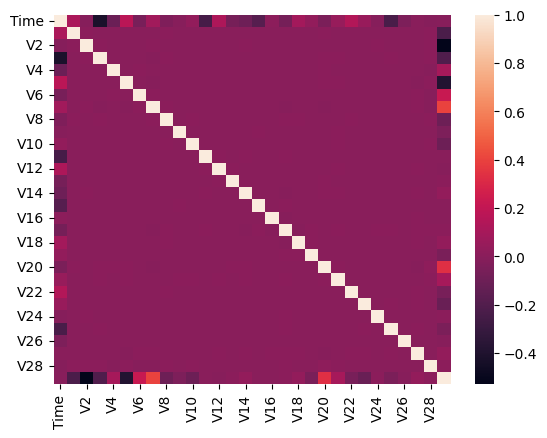

In [24]:
sns.heatmap(a)

In [26]:
sns.pairplot(X_train)

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x10bda3560> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x168262840> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [40]:
y_train.values

array([0, 0, 0, ..., 0, 0, 0], shape=(227845,))

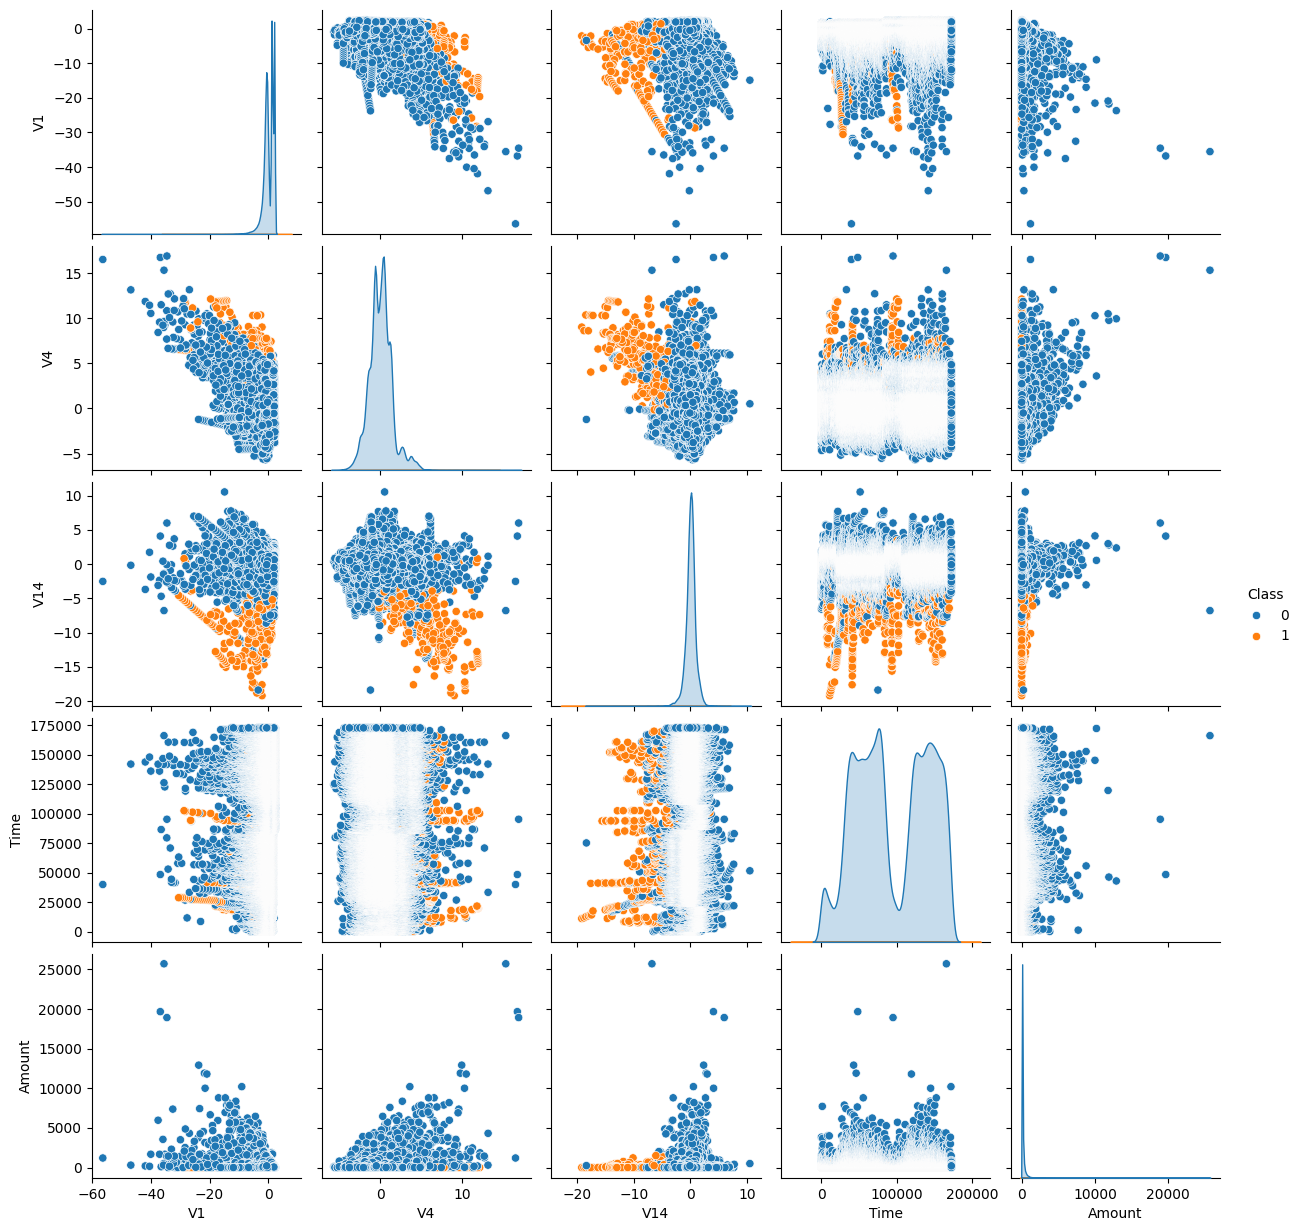

In [41]:
feature_importance = model.get_feature_importance()
feature_names = X_train.columns

# Вывод результатов
feat = pd.DataFrame({"feature": feature_names, "importance": feature_importance})
feat = feat.sort_values(by='importance', ascending=False)
# for name, importance in zip(feature_names, feature_importance):
#     print(f"Feature: {name}, Importance: {importance:.2f}")
features = np.append(feat.head(5)['feature'].values, 'Class')
sns.pairplot(df[features], hue='Class')

In [80]:
# ==========================
# 5. ОПРЕДЕЛЕНИЕ ПОРОГА АНОМАЛЬНОСТИ
# ==========================
# Для обеих моделей нужно выбрать порог, выше которого наблюдение считается аномальным.
# Подход: использовать процентиль 95% (или 99%) от распределения "нормальных" обучающих данных.
# Но в обучающей выборке также могут быть аномалии (хоть и мало). Упрощённо возьмём 99-й процентиль на обучающих предсказаниях.

# Для Isolation Forest: чем ниже score_samples, тем более аномально.
# Получим скоринговую функцию на обучающих данных.
iso_scores_train = iso_forest.decision_function(X_train.drop('Amount', axis=1))

# TODO 5.1: Рассчитайте порог как 5-й процентиль (т.к. меньшие значения – аномалии) для Isolation Forest.
threshold_if = np.percentile(iso_scores_train, 0.17) #??? или 1? Подумайте.

# Для Autoencoder: ошибка реконструкции – чем выше, тем аномальнее. Возьмём 99-й процентиль MSE на обучающих данных.
# mse_train = np.mean((X_train - autoencoder.predict(X_train))**2, axis=1)
threshold_ae = np.percentile(mse_test, 99.83) # <ВАШ_КОД: np.percentile(mse_train, 99)>

In [62]:
df[df['Amount'] > 2000]['Class'].sum()

np.int64(1)

In [81]:
# ==========================
# 6. КЛАССИФИКАЦИЯ И ОЦЕНКА КАЧЕСТВА
# ==========================
# Применяем пороги к тестовым данным.

# Isolation Forest: аномалия, если score < threshold_if
iso_anomaly = (iso_scores < threshold_if).astype(int)

# # Autoencoder: аномалия, если mse > threshold_ae
ae_anomaly = (mse_test > threshold_ae).astype(int)

# TODO 6.1: Напишите функцию для вывода метрик качества (confusion matrix, ROC AUC, Precision-Recall AUC).
# Сравните предсказания (iso_anomaly, ae_anomaly) с истинными метками y_test.
def evaluate_model(y_true, y_pred, y_scores=None, model_name='Model'):
    # Печатает confusion matrix, classification report, а также ROC AUC и PR AUC, если есть scores.
    print(f"classification_report: {classification_report(y_true, y_pred)}")
    print(f"roc_auc_score: {roc_auc_score(y_true, y_pred)}")
    print(f"average_precision_score: {average_precision_score(y_true, y_pred)}")
    print(f"confusion_matrix: {confusion_matrix(y_true, y_pred)}")


# print("=== Оценка Isolation Forest ===")
evaluate_model(y_test, iso_anomaly, y_scores=iso_scores, model_name='Isolation Forest')

# print("=== Оценка Autoencoder ===")
evaluate_model(y_test, ae_anomaly, y_scores=mse_test, model_name='Autoencoder')  # для AE scores – это mse (чем выше, тем аномальнее)


classification_report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.25      0.24      0.25        98

    accuracy                           1.00     56962
   macro avg       0.63      0.62      0.62     56962
weighted avg       1.00      1.00      1.00     56962

roc_auc_score: 0.6218246830245886
average_precision_score: 0.0631680697980537
confusion_matrix: [[56793    71]
 [   74    24]]
classification_report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.25      0.24      0.25        98

    accuracy                           1.00     56962
   macro avg       0.62      0.62      0.62     56962
weighted avg       1.00      1.00      1.00     56962

roc_auc_score: 0.6218070972057929
average_precision_score: 0.06189242117723804
confusion_matrix: [[56791    73]
 [   74    24]]


<Axes: >

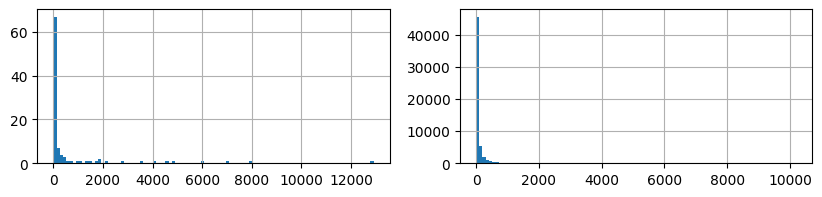

In [75]:
fig, axes = plt.subplots(1,2,figsize=(10, 2))
X_test['Amount'].iloc[np.where(iso_anomaly == 1)[0]].hist(bins=100, ax=axes[0])
X_test['Amount'].iloc[np.where(iso_anomaly == 0)[0]].hist(bins=100, ax=axes[1])

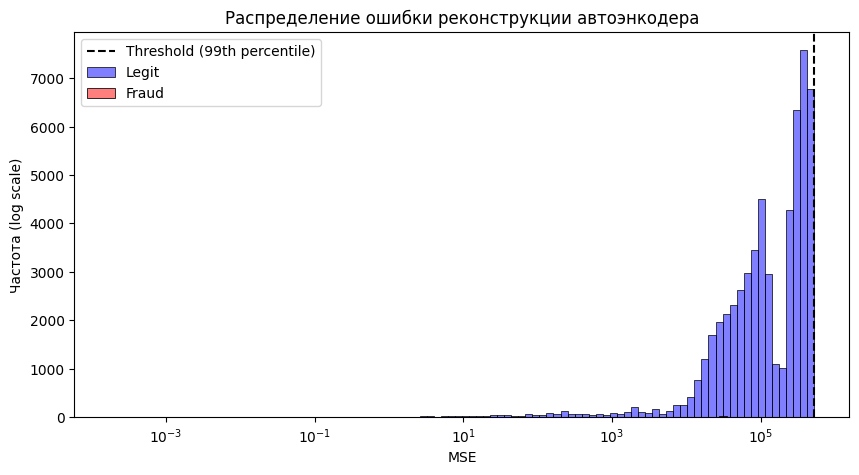

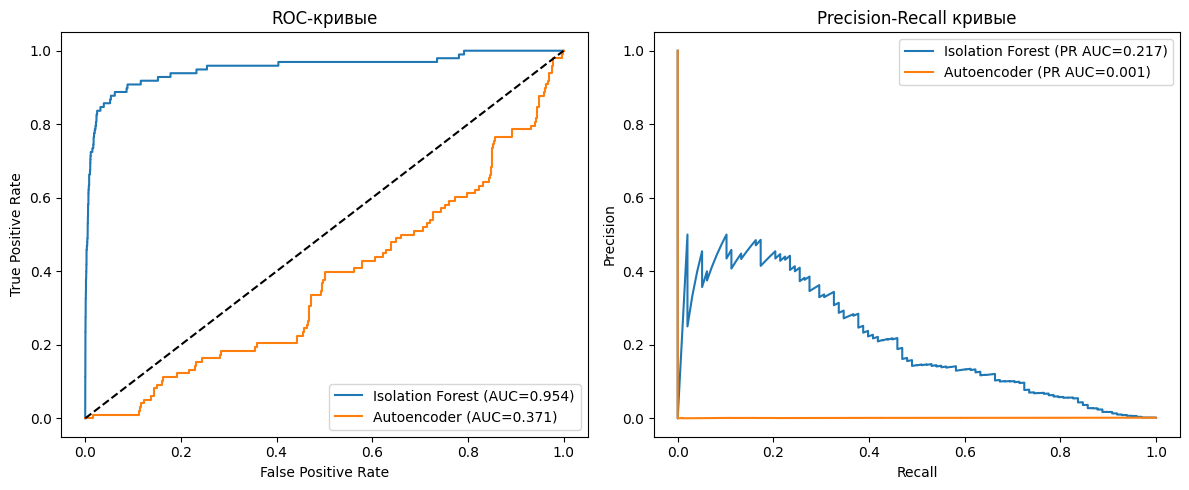

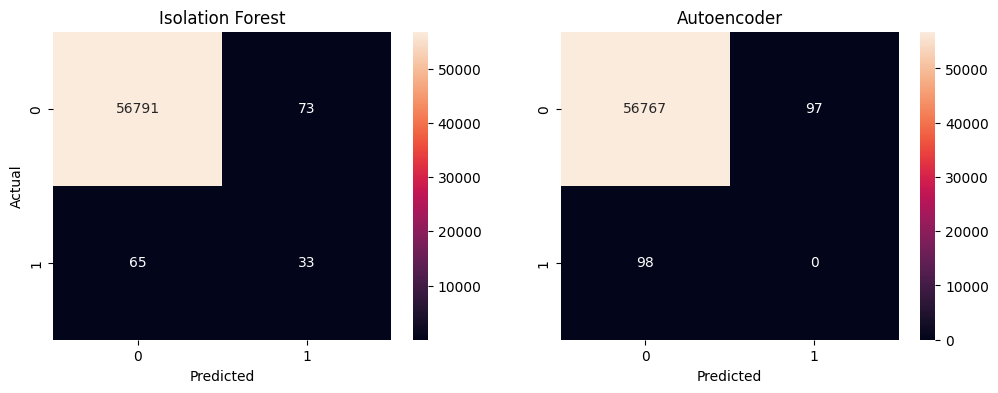

In [10]:
# ==========================
# 7. ВИЗУАЛИЗАЦИЯ
# ==========================
# График 1: Распределение ошибок реконструкции для нормальных и мошеннических транзакций (логарифмическая шкала)
plt.figure(figsize=(10,5))
sns.histplot(mse_test[y_test==0], bins=100, color='blue', label='Legit', alpha=0.5, log_scale=True)
sns.histplot(mse_test[y_test==1], bins=50, color='red', label='Fraud', alpha=0.5, log_scale=True)
plt.axvline(threshold_ae, color='black', linestyle='--', label=f'Threshold (99th percentile)')
plt.title('Распределение ошибки реконструкции автоэнкодера')
plt.xlabel('MSE')
plt.ylabel('Частота (log scale)')
plt.legend()
plt.show()

# График 2: ROC-кривые для обеих моделей
from sklearn.metrics import roc_curve, precision_recall_curve

plt.figure(figsize=(12,5))
# Isolation Forest
fpr_if, tpr_if, _ = roc_curve(y_test, -iso_scores)  # так как меньшие scores – аномалии, берём отрицание
roc_auc_if = roc_auc_score(y_test, -iso_scores)
# Autoencoder
fpr_ae, tpr_ae, _ = roc_curve(y_test, mse_test)
roc_auc_ae = roc_auc_score(y_test, mse_test)

plt.subplot(1,2,1)
plt.plot(fpr_if, tpr_if, label=f'Isolation Forest (AUC={roc_auc_if:.3f})')
plt.plot(fpr_ae, tpr_ae, label=f'Autoencoder (AUC={roc_auc_ae:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()

# Precision-Recall кривые
prec_if, rec_if, _ = precision_recall_curve(y_test, -iso_scores)
pr_auc_if = average_precision_score(y_test, -iso_scores)
prec_ae, rec_ae, _ = precision_recall_curve(y_test, mse_test)
pr_auc_ae = average_precision_score(y_test, mse_test)

plt.subplot(1,2,2)
plt.plot(rec_if, prec_if, label=f'Isolation Forest (PR AUC={pr_auc_if:.3f})')
plt.plot(rec_ae, prec_ae, label=f'Autoencoder (PR AUC={pr_auc_ae:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall кривые')
plt.legend()
plt.tight_layout()
plt.show()

# График 3: Confusion matrices для обеих моделей
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.heatmap(confusion_matrix(y_test, iso_anomaly), annot=True, fmt='d', ax=axes[0])
axes[0].set_title('Isolation Forest')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
sns.heatmap(confusion_matrix(y_test, ae_anomaly), annot=True, fmt='d', ax=axes[1])
axes[1].set_title('Autoencoder')
axes[1].set_xlabel('Predicted')
plt.show()

(0.0, 100.0)

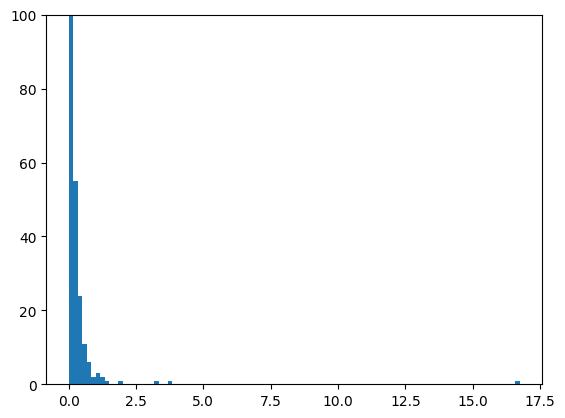

In [ ]:
plt.hist(mse_test, bins=100)
plt.ylim([0,100])